
Dataset size = 1000
Heap insert  : 0.278 ± 0.086 ms
Heap pop     : 0.706 ± 0.111 ms
Heap peek    : 0.084347 ± 0.022256 ms
Heap mem peak: 0.065 MB
Skip insert  : 3.797 ± 5.584 ms
Skip pop     : 0.695 ± 0.168 ms
Skip peek    : 0.079066 ± 0.009213 ms
Skip mem peak: 0.168 MB

Dataset size = 10000
Heap insert  : 8.535 ± 15.093 ms
Heap pop     : 10.701 ± 2.377 ms
Heap peek    : 0.082464 ± 0.011611 ms
Heap mem peak: 0.590 MB
Skip insert  : 44.029 ± 19.696 ms
Skip pop     : 9.015 ± 1.684 ms
Skip peek    : 0.083708 ± 0.013503 ms
Skip mem peak: 1.676 MB

Dataset size = 100000
Heap insert  : 123.987 ± 95.581 ms
Heap pop     : 192.997 ± 23.463 ms
Heap peek    : 0.090456 ± 0.026000 ms
Heap mem peak: 6.289 MB
Skip insert  : 543.818 ± 107.273 ms
Skip pop     : 85.224 ± 9.444 ms
Skip peek    : 0.080375 ± 0.010195 ms
Skip mem peak: 16.802 MB


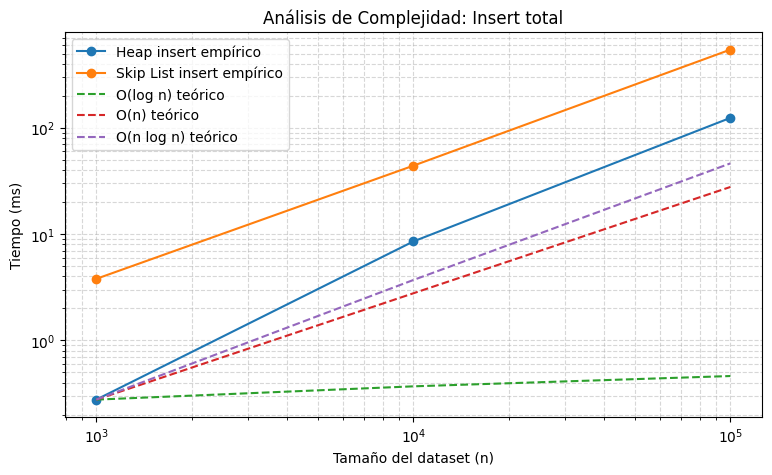

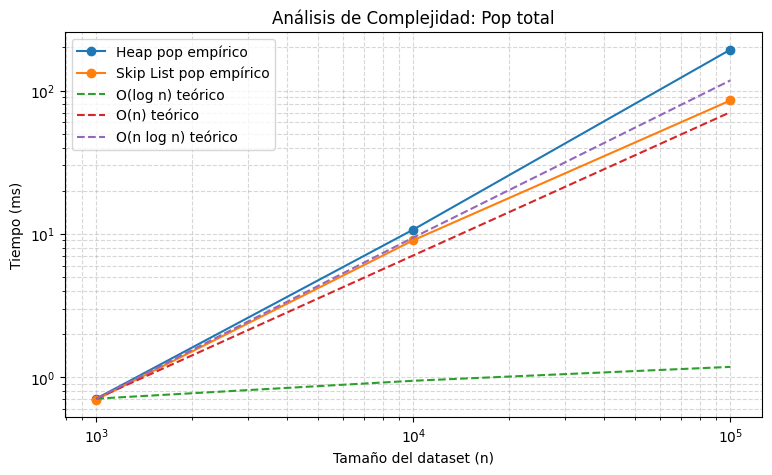

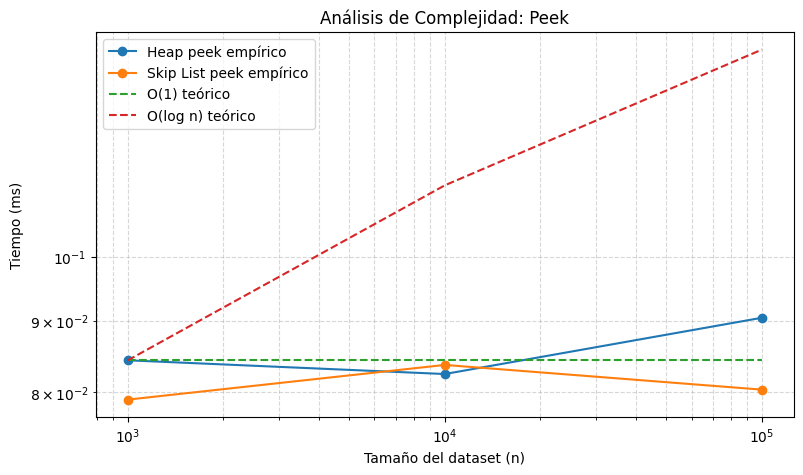

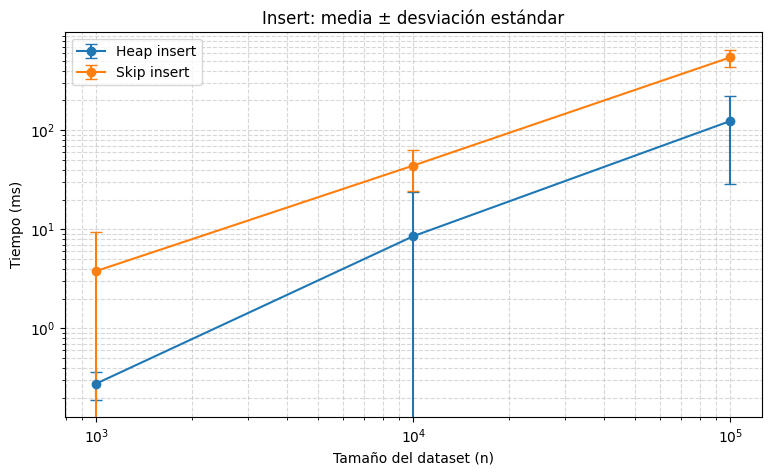

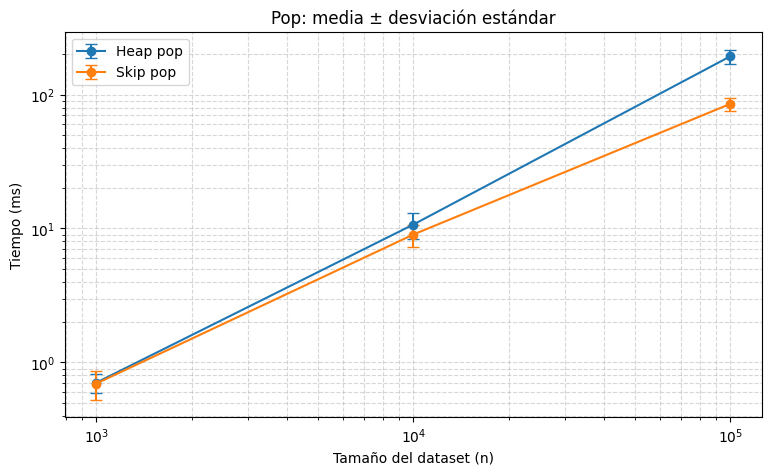

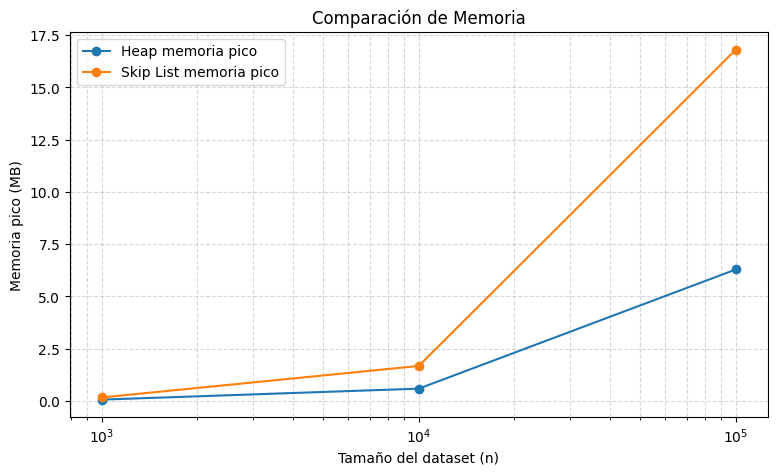


         n |     Heap Insert |        Heap Pop |       Heap Peek |    Heap Mem(MB) |     Skip Insert |        Skip Pop |       Skip Peek |    Skip Mem(MB)
      1000 |           0.278 |           0.706 |        0.084347 |           0.065 |           3.797 |           0.695 |        0.079066 |           0.168
     10000 |           8.535 |          10.701 |        0.082464 |           0.590 |          44.029 |           9.015 |        0.083708 |           1.676
    100000 |         123.987 |         192.997 |        0.090456 |           6.289 |         543.818 |          85.224 |        0.080375 |          16.802


In [1]:
# =========================================================
# EXPERIMENTACIÓN Y ANÁLISIS
# Cola de Procesamiento con Prioridades
# Heap vs Skip List
# =========================================================

import random
import time
import math
import statistics
import tracemalloc
import heapq
import matplotlib.pyplot as plt


# =========================================================
# 1. MODELO DEL PROBLEMA
# =========================================================
# Regla de prioridad:
# 1) Eventos de pago (compras, suscripciones) -> máxima prioridad
# 2) Usuarios premium -> prioridad alta
# 3) Usuarios estándar -> prioridad normal
#
# Para respetar FIFO dentro de la misma prioridad:
# key = (-priority_level, sequence_id)
# Como heapq es min-heap, el menor key sale primero.
# Ejemplo:
#   pago        -> 3
#   premium     -> 2
#   normal      -> 1


def priority_level(user_type, event_type):
    if event_type in ("purchase", "subscription"):
        return 3
    elif user_type == "premium":
        return 2
    else:
        return 1


def generate_dataset(n, seed=42):
    random.seed(seed)
    data = []

    user_types = ["premium", "standard"]
    event_types = ["play", "search", "browse", "purchase", "subscription"]

    # Probabilidades realistas
    user_weights = [0.25, 0.75]  # 25% premium, 75% standard
    event_weights = [0.35, 0.30, 0.20, 0.10, 0.05]

    for seq in range(n):
        user = random.choices(user_types, weights=user_weights, k=1)[0]
        event = random.choices(event_types, weights=event_weights, k=1)[0]
        prio = priority_level(user, event)

        item = {
            "seq": seq,
            "user_type": user,
            "event_type": event,
            "priority": prio,
            "key": (-prio, seq),  # menor key = mayor prioridad, FIFO en empates
        }
        data.append(item)

    return data


# =========================================================
# 2. HEAP PRIORITY QUEUE
# =========================================================
class HeapPriorityQueue:
    def __init__(self):
        self.heap = []

    def insert(self, item):
        heapq.heappush(self.heap, (item["key"], item))

    def pop(self):
        if not self.heap:
            return None
        return heapq.heappop(self.heap)[1]

    def peek(self):
        if not self.heap:
            return None
        return self.heap[0][1]

    def __len__(self):
        return len(self.heap)


# =========================================================
# 3. SKIP LIST PRIORITY QUEUE
# =========================================================
class SkipListNode:
    def __init__(self, key=None, value=None, level=1):
        self.key = key
        self.value = value
        self.forward = [None] * level


class SkipListPriorityQueue:
    def __init__(self, max_level=16, p=0.5):
        self.max_level = max_level
        self.p = p
        self.level = 1
        self.header = SkipListNode(level=max_level)
        self.length = 0

    def random_level(self):
        lvl = 1
        while random.random() < self.p and lvl < self.max_level:
            lvl += 1
        return lvl

    def insert(self, item):
        key = item["key"]
        update = [None] * self.max_level
        current = self.header

        for i in reversed(range(self.level)):
            while current.forward[i] is not None and current.forward[i].key < key:
                current = current.forward[i]
            update[i] = current

        lvl = self.random_level()

        if lvl > self.level:
            for i in range(self.level, lvl):
                update[i] = self.header
            self.level = lvl

        new_node = SkipListNode(key=key, value=item, level=lvl)

        for i in range(lvl):
            new_node.forward[i] = update[i].forward[i]
            update[i].forward[i] = new_node

        self.length += 1

    def pop(self):
        first = self.header.forward[0]
        if first is None:
            return None

        for i in range(self.level):
            if self.header.forward[i] == first:
                self.header.forward[i] = first.forward[i]
            else:
                break

        while self.level > 1 and self.header.forward[self.level - 1] is None:
            self.level -= 1

        self.length -= 1
        return first.value

    def peek(self):
        first = self.header.forward[0]
        return None if first is None else first.value

    def __len__(self):
        return self.length


# =========================================================
# 4. VALIDACIÓN FUNCIONAL
# =========================================================
def demo_priority_order():
    sample = [
        {"seq": 0, "user_type": "standard", "event_type": "play"},
        {"seq": 1, "user_type": "premium", "event_type": "search"},
        {"seq": 2, "user_type": "standard", "event_type": "purchase"},
        {"seq": 3, "user_type": "premium", "event_type": "subscription"},
        {"seq": 4, "user_type": "standard", "event_type": "browse"},
    ]

    for item in sample:
        prio = priority_level(item["user_type"], item["event_type"])
        item["priority"] = prio
        item["key"] = (-prio, item["seq"])

    hpq = HeapPriorityQueue()
    spq = SkipListPriorityQueue()

    for item in sample:
        hpq.insert(item)
        spq.insert(item)

    heap_order = []
    skip_order = []

    while len(hpq) > 0:
        x = hpq.pop()
        heap_order.append((x["seq"], x["user_type"], x["event_type"], x["priority"]))

    while len(spq) > 0:
        x = spq.pop()
        skip_order.append((x["seq"], x["user_type"], x["event_type"], x["priority"]))

    print("Orden Heap:")
    for row in heap_order:
        print(row)

    print("\nOrden Skip List:")
    for row in skip_order:
        print(row)


# Descomenta si quieres probar la lógica primero
# demo_priority_order()


# =========================================================
# 5. MEDICIÓN DE OPERACIONES CRÍTICAS
# =========================================================
# Operaciones críticas:
# - insert
# - pop
# - peek (opcional)
#
# Aquí medimos tiempo total por lote, que luego se compara con curvas teóricas.
# Si insertas n elementos, el costo total esperado para Heap y Skip List es ~ O(n log n).


def benchmark_insert(structure_class, data):
    structure = structure_class()
    t0 = time.perf_counter()
    for item in data:
        structure.insert(item)
    t1 = time.perf_counter()
    return structure, (t1 - t0) * 1000  # ms


def benchmark_pop(structure):
    t0 = time.perf_counter()
    while len(structure) > 0:
        structure.pop()
    t1 = time.perf_counter()
    return (t1 - t0) * 1000  # ms


def benchmark_peek(structure, repeats=1000):
    if len(structure) == 0:
        return 0.0
    t0 = time.perf_counter()
    for _ in range(repeats):
        structure.peek()
    t1 = time.perf_counter()
    return (t1 - t0) * 1000  # ms


# =========================================================
# 6. ANÁLISIS DE MEMORIA
# =========================================================
def memory_test(structure_class, data):
    tracemalloc.start()
    structure = structure_class()
    for item in data:
        structure.insert(item)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return current / 10**6, peak / 10**6  # MB


# =========================================================
# 7. CURVAS TEÓRICAS
# =========================================================
def scale_curve(reference_times, base_curve):
    factor = reference_times[0] / base_curve[0]
    return [factor * x for x in base_curve]


def make_theoretical_curves(sizes, reference_times):
    O1 = scale_curve(reference_times, [1 for _ in sizes])
    Ologn = scale_curve(reference_times, [math.log2(n) for n in sizes])
    On = scale_curve(reference_times, [n for n in sizes])
    Onlogn = scale_curve(reference_times, [n * math.log2(n) for n in sizes])
    return O1, Ologn, On, Onlogn


# =========================================================
# 8. EXPERIMENTACIÓN COMPLETA
# =========================================================
def run_full_experiment(sizes, repeats=100, seed_base=1000):
    results = {
        "heap_insert_mean": [],
        "heap_insert_std": [],
        "heap_pop_mean": [],
        "heap_pop_std": [],
        "heap_peek_mean": [],
        "heap_peek_std": [],
        "heap_mem_current": [],
        "heap_mem_peak": [],

        "skip_insert_mean": [],
        "skip_insert_std": [],
        "skip_pop_mean": [],
        "skip_pop_std": [],
        "skip_peek_mean": [],
        "skip_peek_std": [],
        "skip_mem_current": [],
        "skip_mem_peak": [],
    }

    for idx, n in enumerate(sizes):
        print(f"\n==============================")
        print(f"Dataset size = {n}")
        print(f"==============================")

        heap_insert_times = []
        heap_pop_times = []
        heap_peek_times = []

        skip_insert_times = []
        skip_pop_times = []
        skip_peek_times = []

        # Memoria: una vez por tamaño
        memory_data = generate_dataset(n, seed=seed_base + idx)
        h_cur, h_peak = memory_test(HeapPriorityQueue, memory_data)
        s_cur, s_peak = memory_test(SkipListPriorityQueue, memory_data)

        results["heap_mem_current"].append(h_cur)
        results["heap_mem_peak"].append(h_peak)
        results["skip_mem_current"].append(s_cur)
        results["skip_mem_peak"].append(s_peak)

        for r in range(repeats):
            data = generate_dataset(n, seed=seed_base + idx * 1000 + r)

            # Heap
            heap_structure, heap_insert_ms = benchmark_insert(HeapPriorityQueue, data)
            heap_pop_ms = benchmark_pop(heap_structure)

            # reconstrucción para peek
            heap_structure2, _ = benchmark_insert(HeapPriorityQueue, data)
            heap_peek_ms = benchmark_peek(heap_structure2, repeats=1000)

            heap_insert_times.append(heap_insert_ms)
            heap_pop_times.append(heap_pop_ms)
            heap_peek_times.append(heap_peek_ms)

            # Skip List
            skip_structure, skip_insert_ms = benchmark_insert(SkipListPriorityQueue, data)
            skip_pop_ms = benchmark_pop(skip_structure)

            skip_structure2, _ = benchmark_insert(SkipListPriorityQueue, data)
            skip_peek_ms = benchmark_peek(skip_structure2, repeats=1000)

            skip_insert_times.append(skip_insert_ms)
            skip_pop_times.append(skip_pop_ms)
            skip_peek_times.append(skip_peek_ms)

        # Heap stats
        results["heap_insert_mean"].append(statistics.mean(heap_insert_times))
        results["heap_insert_std"].append(statistics.stdev(heap_insert_times))
        results["heap_pop_mean"].append(statistics.mean(heap_pop_times))
        results["heap_pop_std"].append(statistics.stdev(heap_pop_times))
        results["heap_peek_mean"].append(statistics.mean(heap_peek_times))
        results["heap_peek_std"].append(statistics.stdev(heap_peek_times))

        # Skip stats
        results["skip_insert_mean"].append(statistics.mean(skip_insert_times))
        results["skip_insert_std"].append(statistics.stdev(skip_insert_times))
        results["skip_pop_mean"].append(statistics.mean(skip_pop_times))
        results["skip_pop_std"].append(statistics.stdev(skip_pop_times))
        results["skip_peek_mean"].append(statistics.mean(skip_peek_times))
        results["skip_peek_std"].append(statistics.stdev(skip_peek_times))

        print(f"Heap insert  : {results['heap_insert_mean'][-1]:.3f} ± {results['heap_insert_std'][-1]:.3f} ms")
        print(f"Heap pop     : {results['heap_pop_mean'][-1]:.3f} ± {results['heap_pop_std'][-1]:.3f} ms")
        print(f"Heap peek    : {results['heap_peek_mean'][-1]:.6f} ± {results['heap_peek_std'][-1]:.6f} ms")
        print(f"Heap mem peak: {results['heap_mem_peak'][-1]:.3f} MB")

        print(f"Skip insert  : {results['skip_insert_mean'][-1]:.3f} ± {results['skip_insert_std'][-1]:.3f} ms")
        print(f"Skip pop     : {results['skip_pop_mean'][-1]:.3f} ± {results['skip_pop_std'][-1]:.3f} ms")
        print(f"Skip peek    : {results['skip_peek_mean'][-1]:.6f} ± {results['skip_peek_std'][-1]:.6f} ms")
        print(f"Skip mem peak: {results['skip_mem_peak'][-1]:.3f} MB")

    return results


# =========================================================
# 9. PARÁMETROS
# =========================================================
# Requisito de rúbrica:
# 1K, 10K, 100K, 1M, 10M
#
# OJO:
# 10M con 100 repeticiones puede ser demasiado pesado en Colab.
# Empieza con hasta 1M y luego activa 10M si tu entorno aguanta.

sizes = [10**3, 10**4, 10**5]
# sizes = [10**3, 10**4, 10**5, 10**6, 10**7]

repeats = 100


# =========================================================
# 10. EJECUTAR EXPERIMENTO
# =========================================================
results = run_full_experiment(sizes=sizes, repeats=repeats)


# =========================================================
# 11. GRÁFICOS LOG-LOG: INSERT
# =========================================================
heap_insert = results["heap_insert_mean"]
skip_insert = results["skip_insert_mean"]

O1, Ologn, On, Onlogn = make_theoretical_curves(sizes, heap_insert)

plt.figure(figsize=(9, 5))
plt.loglog(sizes, heap_insert, 'o-', label='Heap insert empírico')
plt.loglog(sizes, skip_insert, 'o-', label='Skip List insert empírico')
plt.loglog(sizes, Ologn, '--', label='O(log n) teórico')
plt.loglog(sizes, On, '--', label='O(n) teórico')
plt.loglog(sizes, Onlogn, '--', label='O(n log n) teórico')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.legend()
plt.title('Análisis de Complejidad: Insert total')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 12. GRÁFICOS LOG-LOG: POP
# =========================================================
heap_pop = results["heap_pop_mean"]
skip_pop = results["skip_pop_mean"]

O1, Ologn, On, Onlogn = make_theoretical_curves(sizes, heap_pop)

plt.figure(figsize=(9, 5))
plt.loglog(sizes, heap_pop, 'o-', label='Heap pop empírico')
plt.loglog(sizes, skip_pop, 'o-', label='Skip List pop empírico')
plt.loglog(sizes, Ologn, '--', label='O(log n) teórico')
plt.loglog(sizes, On, '--', label='O(n) teórico')
plt.loglog(sizes, Onlogn, '--', label='O(n log n) teórico')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.legend()
plt.title('Análisis de Complejidad: Pop total')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 13. GRÁFICOS LOG-LOG: PEEK
# =========================================================
heap_peek = results["heap_peek_mean"]
skip_peek = results["skip_peek_mean"]

O1, Ologn, On, Onlogn = make_theoretical_curves(sizes, heap_peek)

plt.figure(figsize=(9, 5))
plt.loglog(sizes, heap_peek, 'o-', label='Heap peek empírico')
plt.loglog(sizes, skip_peek, 'o-', label='Skip List peek empírico')
plt.loglog(sizes, O1, '--', label='O(1) teórico')
plt.loglog(sizes, Ologn, '--', label='O(log n) teórico')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.legend()
plt.title('Análisis de Complejidad: Peek')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 14. BARRAS DE ERROR (DESVIACIÓN ESTÁNDAR)
# =========================================================
plt.figure(figsize=(9, 5))
plt.errorbar(sizes, results["heap_insert_mean"], yerr=results["heap_insert_std"], fmt='o-', capsize=4, label='Heap insert')
plt.errorbar(sizes, results["skip_insert_mean"], yerr=results["skip_insert_std"], fmt='o-', capsize=4, label='Skip insert')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.title('Insert: media ± desviación estándar')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

plt.figure(figsize=(9, 5))
plt.errorbar(sizes, results["heap_pop_mean"], yerr=results["heap_pop_std"], fmt='o-', capsize=4, label='Heap pop')
plt.errorbar(sizes, results["skip_pop_mean"], yerr=results["skip_pop_std"], fmt='o-', capsize=4, label='Skip pop')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Tiempo (ms)')
plt.title('Pop: media ± desviación estándar')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 15. ANÁLISIS DE MEMORIA
# =========================================================
plt.figure(figsize=(9, 5))
plt.plot(sizes, results["heap_mem_peak"], 'o-', label='Heap memoria pico')
plt.plot(sizes, results["skip_mem_peak"], 'o-', label='Skip List memoria pico')
plt.xscale('log')
plt.xlabel('Tamaño del dataset (n)')
plt.ylabel('Memoria pico (MB)')
plt.title('Comparación de Memoria')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


# =========================================================
# 16. RESUMEN FINAL
# =========================================================
print("\n" + "=" * 110)
print(f"{'n':>10} | {'Heap Insert':>15} | {'Heap Pop':>15} | {'Heap Peek':>15} | {'Heap Mem(MB)':>15} | {'Skip Insert':>15} | {'Skip Pop':>15} | {'Skip Peek':>15} | {'Skip Mem(MB)':>15}")
print("=" * 110)

for i, n in enumerate(sizes):
    print(
        f"{n:>10} | "
        f"{results['heap_insert_mean'][i]:>15.3f} | "
        f"{results['heap_pop_mean'][i]:>15.3f} | "
        f"{results['heap_peek_mean'][i]:>15.6f} | "
        f"{results['heap_mem_peak'][i]:>15.3f} | "
        f"{results['skip_insert_mean'][i]:>15.3f} | "
        f"{results['skip_pop_mean'][i]:>15.3f} | "
        f"{results['skip_peek_mean'][i]:>15.6f} | "
        f"{results['skip_mem_peak'][i]:>15.3f}"
    )